Module 4: Introduction to Fully Connected NN

Problem Statement:
Fashion MNIST is a dataset comprising 60,000 training images and 10,000
testing images, each depicting various fashion items in a 28x28 grayscale format.
The dataset encompasses ten distinct categories of apparel. The primary aim of
this assignment is to develop a fully connected neural network (FCNN) that can
accurately classify these images into the correct fashion categories

Objectives:
Data Visualization and Preprocessing:
● Visualize the distribution of different fashion items in the dataset to
understand the data better.
● Normalize the image pixel values for effective model training.
● Convert the categorical labels into a one-hot encoded format to suit the
neural network’s output layer

Model Architecture and Development:
● Design a fully connected neural network with appropriate input, hidden,
and output layers.
● Ensure the model is complex enough to capture the underlying patterns in
the data without overfit● ting

Model Training
Train the model on the preprocessed training data, using categorical
cross-entropy as the loss function, stochastic gradient descent as the
optimizer, and accuracy ● as the evaluation metric.
Utlize a validation split to monitor the model’s performance on unseen
data during training.

Performance Evaluation:
● Assess the model’s performance using both training and validation
datasets.
● Visualize the training and validation loss and accuracy to identify any signs
of overfitting or underfitting


Load Fashion MNIST Dataset

In [2]:
from tensorflow.keras.datasets import fashion_mnist

# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Fashion MNIST dataset loaded successfully.")
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Testing images shape: {test_images.shape}")
print(f"Testing labels shape: {test_labels.shape}")

Fashion MNIST dataset loaded successfully.
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


Data Visualization

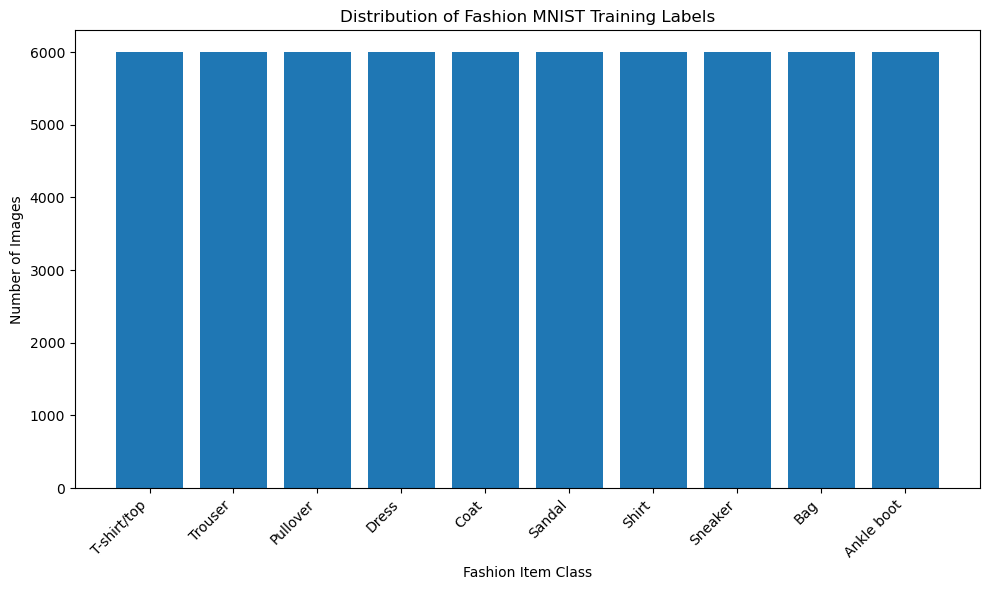

Label distribution successfully visualized.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
unique_labels, counts = np.unique(train_labels, return_counts=True)

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(unique_labels, counts, tick_label=[class_names[i] for i in unique_labels])
plt.title('Distribution of Fashion MNIST Training Labels')
plt.xlabel('Fashion Item Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Label distribution successfully visualized.")

Data Preprocessing

In [6]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print("Image pixel values normalized.")
print(f"Normalized training images data type: {train_images.dtype}")
print(f"Normalized testing images data type: {test_images.dtype}")
print(f"First 5 pixel values of a training image after normalization:\n{train_images[0, :5, :5]}")

Image pixel values normalized.
Normalized training images data type: float32
Normalized testing images data type: float32
First 5 pixel values of a training image after normalization:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [7]:
from tensorflow.keras.utils import to_categorical

# Get the number of classes (0-9 for Fashion MNIST)
num_classes = len(np.unique(train_labels))

# Convert labels to one-hot encoded format
train_labels_one_hot = to_categorical(train_labels, num_classes=num_classes)
test_labels_one_hot = to_categorical(test_labels, num_classes=num_classes)

print("Labels converted to one-hot encoded format.")
print(f"Original training labels shape: {train_labels.shape}")
print(f"One-hot encoded training labels shape: {train_labels_one_hot.shape}")
print(f"Original testing labels shape: {test_labels.shape}")
print(f"One-hot encoded testing labels shape: {test_labels_one_hot.shape}")
print(f"First 5 one-hot encoded training labels:\n{train_labels_one_hot[:5]}")

Labels converted to one-hot encoded format.
Original training labels shape: (60000,)
One-hot encoded training labels shape: (60000, 10)
Original testing labels shape: (10000,)
One-hot encoded testing labels shape: (10000, 10)
First 5 one-hot encoded training labels:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


Model Architecture and Development

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Define the model architecture
model = Sequential([
    Flatten(input_shape=(28, 28)), 
    Dense(128, activation='relu'),  
    Dense(64, activation='relu'),   
    Dense(num_classes, activation='softmax')
])

model.summary()
print("FCNN model designed successfully.")

C:\Users\Durga\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

FCNN model designed successfully.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.optimizers import SGD # Import SGD optimizer

# Define the model architecture

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),             
    Dense(128, activation='relu'),  
    Dense(64, activation='relu'),  
    Dense(num_classes, activation='softmax') 
])

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("FCNN model designed and compiled successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

FCNN model designed and compiled successfully.


Model Training

In [20]:
history = model.fit(
    train_images,
    train_labels_one_hot,
    epochs=10,
    batch_size=32, 
    validation_split=0.2 
)

print("Model training complete. Training history stored in 'history' variable.")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6322 - loss: 1.1113 - val_accuracy: 0.8105 - val_loss: 0.5593
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8142 - loss: 0.5387 - val_accuracy: 0.8187 - val_loss: 0.5090
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8384 - loss: 0.4685 - val_accuracy: 0.8428 - val_loss: 0.4568
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8488 - loss: 0.4366 - val_accuracy: 0.8437 - val_loss: 0.4420
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8528 - loss: 0.4253 - val_accuracy: 0.8542 - val_loss: 0.4193
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8578 - loss: 0.4062 - val_accuracy: 0.8578 - val_loss: 0.4050
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8657 - loss: 0.3834 - val_accuracy: 0.8516 - val_loss: 0.4244
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8692 - loss: 0.3727 - 

Performance Evaluation

In [22]:
train_loss, train_accuracy = model.evaluate(train_images, train_labels_one_hot, verbose=0)
test_loss, test_accuracy = model.evaluate(test_images, test_labels_one_hot, verbose=0)

print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Loss: 0.3928
Training Accuracy: 0.8573
Test Loss: 0.4424
Test Accuracy: 0.8389


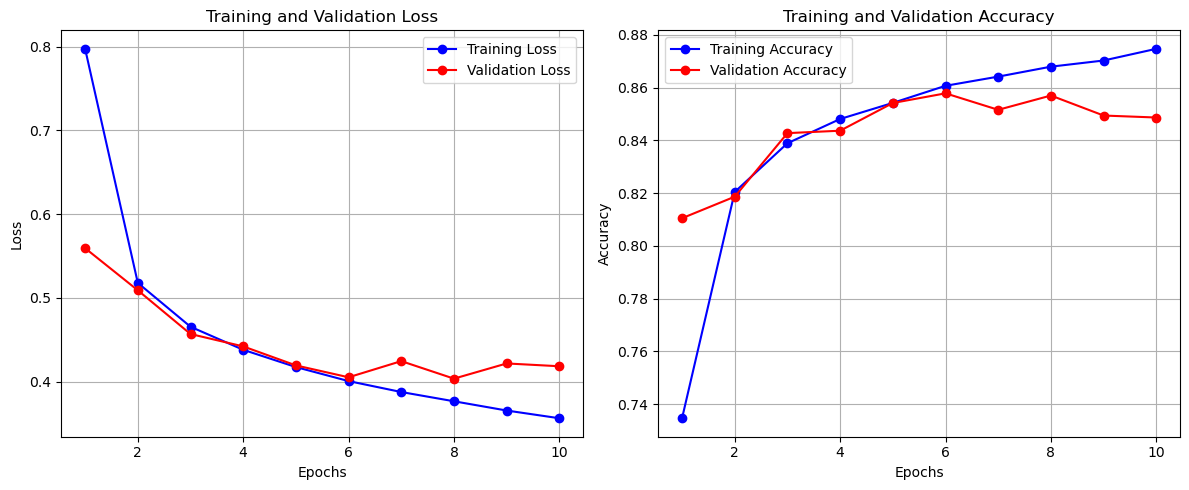

Training and validation loss and accuracy plots generated successfully.


In [23]:
import matplotlib.pyplot as plt

# Get training and validation metrics from history object
hist = history.history
loss = hist['loss']
val_loss = hist['val_loss']
accuracy = hist['accuracy']
val_accuracy = hist['val_accuracy']
epochs = range(1, len(loss) + 1)

# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) 
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Training and validation loss and accuracy plots generated successfully.")

Summary:
Model Performance: The Fully Connected Neural Network (FCNN) achieved a training accuracy of 85.73% and a test accuracy of 83.89%. The training loss was 39.28%, and the test loss was 44.24%.